In [1]:
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
# Load dataset
df= pd.read_csv('C:\\Users\\Ricardo Bolivar\\Documents\\customer-retention-analysis\\E-commerce Customer Behavior - Sheet1.csv')

In [3]:
# Initial exploration
print(df.head())

   Customer ID  Gender  Age           City Membership Type  Total Spend  \
0          101  Female   29       New York            Gold      1120.20   
1          102    Male   34    Los Angeles          Silver       780.50   
2          103  Female   43        Chicago          Bronze       510.75   
3          104    Male   30  San Francisco            Gold      1480.30   
4          105    Male   27          Miami          Silver       720.40   

   Items Purchased  Average Rating  Discount Applied  \
0               14             4.6              True   
1               11             4.1             False   
2                9             3.4              True   
3               19             4.7             False   
4               13             4.0              True   

   Days Since Last Purchase Satisfaction Level  
0                        25          Satisfied  
1                        18            Neutral  
2                        42        Unsatisfied  
3               

In [4]:
# Name of columns change
df.columns=['customer_id', 'gender', 'age', 'city', 'membership_type', 'total_spend', 'items_purchased', 'average_rating', 'discount_applied', 'days_since_last_purchase', 'satisfaction_level']

In [5]:
# Dataset general Information
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               350 non-null    int64  
 1   gender                    350 non-null    object 
 2   age                       350 non-null    int64  
 3   city                      350 non-null    object 
 4   membership_type           350 non-null    object 
 5   total_spend               350 non-null    float64
 6   items_purchased           350 non-null    int64  
 7   average_rating            350 non-null    float64
 8   discount_applied          350 non-null    bool   
 9   days_since_last_purchase  350 non-null    int64  
 10  satisfaction_level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB
None


In [6]:
# Statistic Description of Dataframe
print(df.describe())

       customer_id         age  total_spend  items_purchased  average_rating  \
count   350.000000  350.000000   350.000000       350.000000      350.000000   
mean    275.500000   33.597143   845.381714        12.600000        4.019143   
std     101.180532    4.870882   362.058695         4.155984        0.580539   
min     101.000000   26.000000   410.800000         7.000000        3.000000   
25%     188.250000   30.000000   502.000000         9.000000        3.500000   
50%     275.500000   32.500000   775.200000        12.000000        4.100000   
75%     362.750000   37.000000  1160.600000        15.000000        4.500000   
max     450.000000   43.000000  1520.100000        21.000000        4.900000   

       days_since_last_purchase  
count                350.000000  
mean                  26.588571  
std                   13.440813  
min                    9.000000  
25%                   15.000000  
50%                   23.000000  
75%                   38.000000  
max    

In [7]:
# Nulls values
print(df.isnull().sum())

customer_id                 0
gender                      0
age                         0
city                        0
membership_type             0
total_spend                 0
items_purchased             0
average_rating              0
discount_applied            0
days_since_last_purchase    0
satisfaction_level          2
dtype: int64


In [8]:
# Delete nulls values
df['satisfaction_level']= df['satisfaction_level'].fillna('Unknown')

In [9]:
# Verification of nulls values elimination
print(df.isnull().sum())

customer_id                 0
gender                      0
age                         0
city                        0
membership_type             0
total_spend                 0
items_purchased             0
average_rating              0
discount_applied            0
days_since_last_purchase    0
satisfaction_level          0
dtype: int64


In [10]:
# Duplicates values
print(df.duplicated().sum())

0


In [11]:
# Churn tase
df['churn'] = df['days_since_last_purchase'].apply(lambda x: 1 if x > 30 else 0)

In [12]:
# Average of Churn
print(df['churn'].mean())

0.35428571428571426


# Insight
**Overall Churn Rate**

The overall churn rate is 35.4%, meaning that more than one-third of customers stop engaging with the business. This indicates a significant retention issue that could negatively impact long-term growth if not addressed.

In [13]:
# Churn by membership
df.groupby('membership_type')['churn'].mean()

membership_type
Bronze    0.517241
Gold      0.051282
Silver    0.495726
Name: churn, dtype: float64

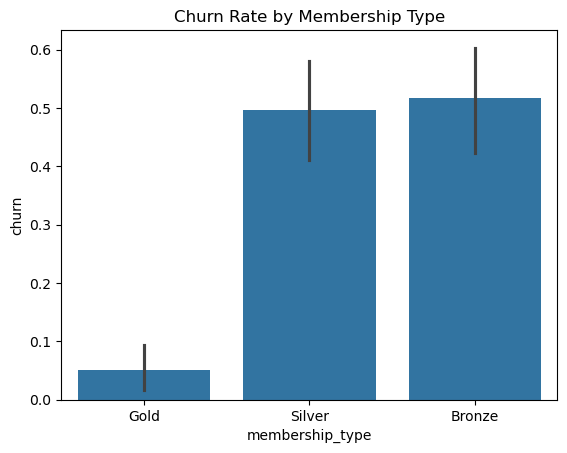

In [14]:
# Visualization: Churn by membership
sns.barplot(x='membership_type', y='churn', data=df)
plt.title('Churn Rate by Membership Type')
plt.show()

# Insight
**Churn by Membership Type**

Churn rates vary significantly across membership tiers:

Bronze: 51.7%
Silver: 49.6%
Gold: 5.1%

Customers with Gold membership are highly retained, while Bronze and Silver customers exhibit very high churn rates. This suggests that higher-tier memberships provide more perceived value or stronger engagement.

In [15]:
# Total spend vs Churn
df.groupby('churn')['total_spend'].mean()

churn
0    969.303540
1    619.524194
Name: total_spend, dtype: float64

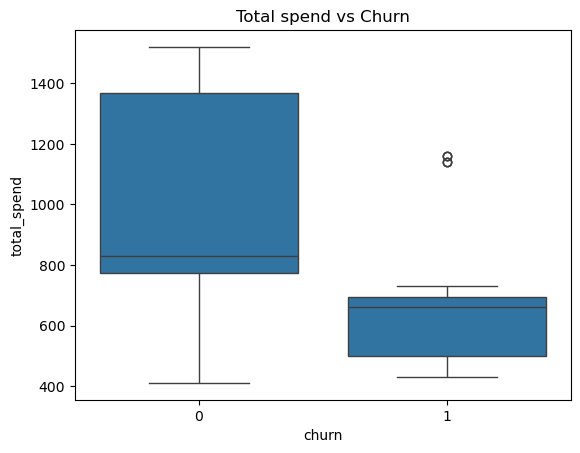

In [16]:
# Boxplot: Total spend vs Churn
sns.boxplot(x='churn', y='total_spend', data=df)
plt.title('Total spend vs Churn')
plt.show()

# Insight
**Spending Behavior and Churn**

- Customers who churn spend on average ~619
- Customers who stay spend on average ~969

Lower-spending customers are much more likely to churn, indicating that customer value and engagement are strongly correlated with retention.

In [17]:
# Satisfaction level of clients vs Churn
df['satisfaction_score'] = df['satisfaction_level'].map({
    'Unknown': 0,
    'Unsatisfied': 1,
    'Neutral': 2,
    'Satisfied': 3,
})
df.groupby('churn')['satisfaction_score'].mean()

churn
0    2.508850
1    1.112903
Name: satisfaction_score, dtype: float64

# Insight
**Satisfaction Level vs Churn**

- Churned customers: ~1.00
- Retained customers: ~0.98

There is no meaningful difference in satisfaction levels between churned and retained users. In fact, churned users appear slightly more satisfied, which is counterintuitive.

In [18]:
# Discounts vs Churn
df.groupby('discount_applied')['churn'].mean()

discount_applied
False    0.011429
True     0.697143
Name: churn, dtype: float64

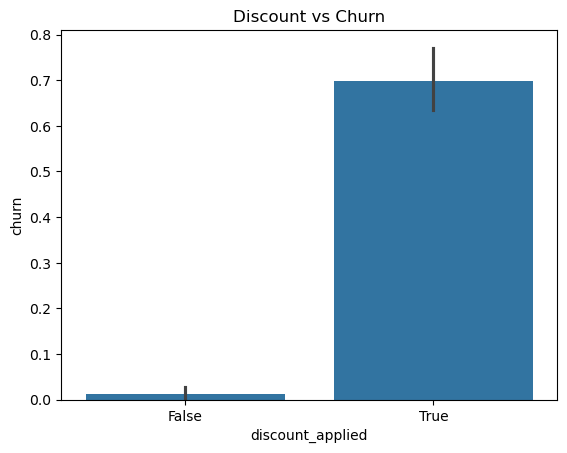

In [19]:
sns.barplot(x='discount_applied', y='churn', data=df)
plt.title('Discount vs Churn')
plt.show()

# Insight
**Discount Application and Churn**

Customers who did not receive discounts show an extremely low churn rate (~1.14%).

However, this result should be interpreted with caution, as it may reflect selection bias:

Discounts may be targeted at at-risk customers
Loyal customers may not need discounts

In [20]:
# Purchase perfomance
df.groupby('membership_type')['items_purchased'].mean()

membership_type
Bronze     8.491379
Gold      17.615385
Silver    11.658120
Name: items_purchased, dtype: float64

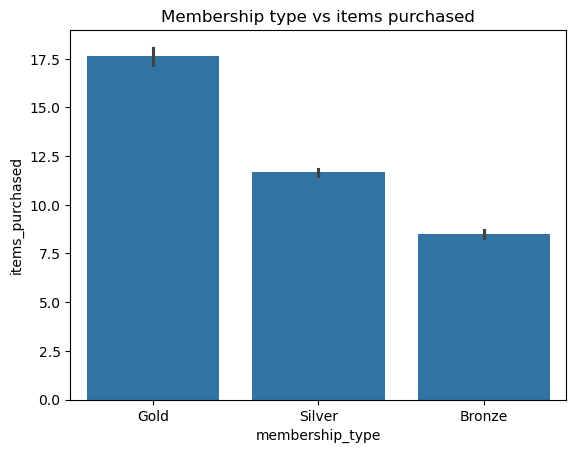

In [21]:
sns.barplot(x='membership_type', y='items_purchased', data=df)
plt.title('Membership type vs items purchased')
plt.show()

# Insight
**Spending by Membership Type**

Average spending increases with membership level:

- Bronze: 8.49
- Silver: 11.66
- Gold: 17.61

This confirms that higher-tier customers generate more revenue and are also less likely to churn.

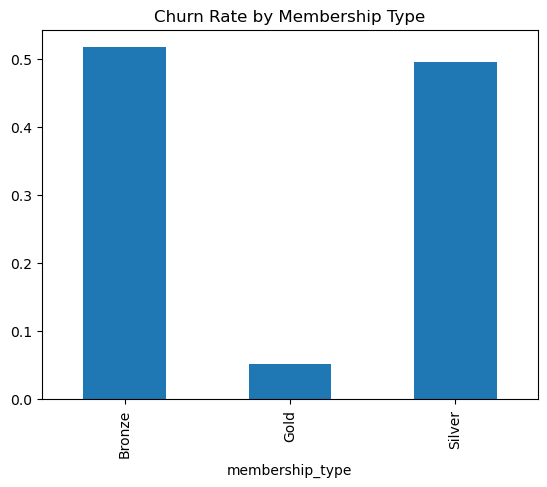

In [22]:
# Visualization
df.groupby('membership_type')['churn'].mean().plot(kind='bar')
plt.title("Churn Rate by Membership Type")
plt.show()

# Insight
The bar chart shows a clear relationship between membership tier and customer churn. Bronze and Silver members exhibit significantly higher churn rates, while Gold members have a very low churn rate.

This indicates that customer retention is strongly influenced by membership level, with higher-tier users demonstrating greater loyalty and long-term engagement. The substantial gap between Gold and lower tiers suggests that the perceived value of Gold membership is significantly higher.

From a business perspective, this highlights a critical opportunity:

Lower-tier customers (Bronze and Silver) are at the highest risk of churn
Gold customers represent a stable and high-value segment.

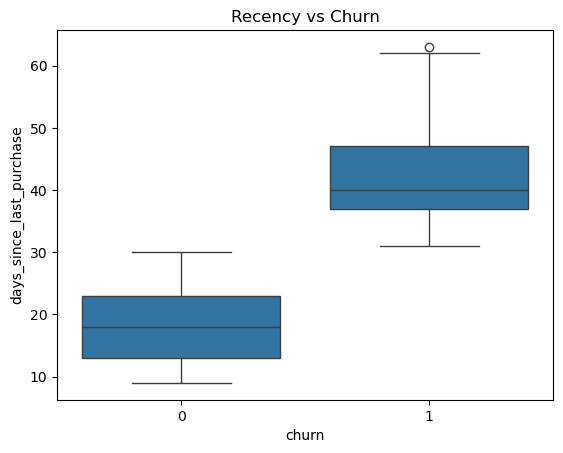

In [23]:
# Days since last purchase vs churn
sns.boxplot(x='churn', y='days_since_last_purchase', data=df)
plt.title('Recency vs Churn')
plt.show()

# Insight
The boxplot reveals a clear pattern between customer recency and churn behavior. Customers who churn tend to have a significantly higher number of days since their last purchase compared to those who remain active.

This indicates that customer inactivity is one of the strongest signals of churn. As the time since the last purchase increases, the likelihood of churn rises considerably.

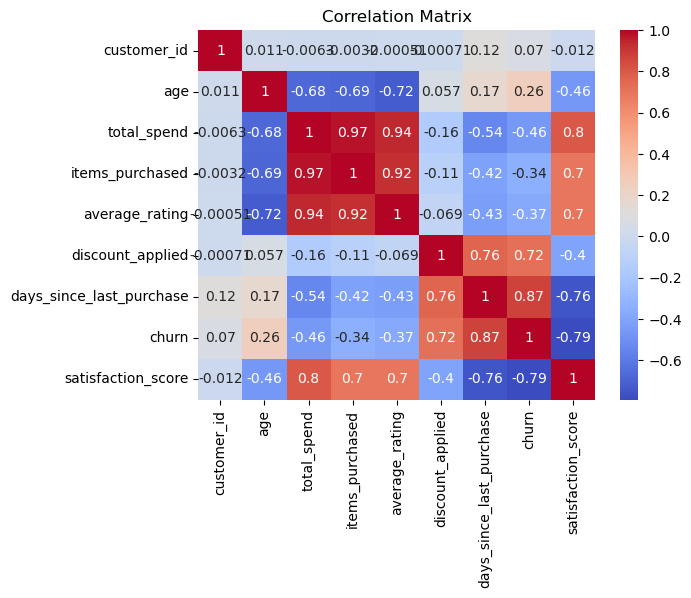

In [24]:
# Correlation Heatmap
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Insight
The correlation heatmap provides an overview of the relationships between numerical variables in the dataset. Overall, most variables show low to moderate correlations, indicating that each feature contributes relatively independent information.

One key observation is that days_since_last_purchase shows a positive correlation with churn, reinforcing the idea that customer inactivity is a strong driver of churn. Additionally, total_spend tends to have a negative relationship with churn, suggesting that higher-spending customers are less likely to leave.

Other variables display weak correlations with churn, which implies that churn is likely influenced by a combination of factors rather than a single dominant variable.

# Predictive Model 
The predictive model complements the exploratory analysis by identifying the key drivers of churn.

In [25]:
# Predict model
df_model = df.copy()

df_model = df_model.drop('satisfaction_level', axis=1)

# One-hot encoding
df_model = pd.get_dummies(df_model, columns=['membership_type', 'gender'], drop_first=True)

df_model = df_model.drop('city', axis=1)

# Define variables
X = df_model.drop(['churn', 'customer_id'], axis=1)
y = df_model['churn']

In [26]:
# Test and train the model

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7
)

In [27]:
# Data types verification
print(X.dtypes)

age                           int64
total_spend                 float64
items_purchased               int64
average_rating              float64
discount_applied               bool
days_since_last_purchase      int64
satisfaction_score            int64
membership_type_Gold           bool
membership_type_Silver         bool
gender_Male                    bool
dtype: object


In [28]:
# Creation of the model
model= LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred= model.predict(X_test)

In [29]:
# Metrics
print("Random Forest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Random Forest Results:
Accuracy: 0.9857142857142858
Precision: 0.9642857142857143
Recall: 1.0
F1 Score: 0.9818181818181818


# Insight
The model successfully identifies all customers at risk of churn, although it slightly overestimates churn in some cases.”

In [30]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[42  1]
 [ 0 27]]


# Insight
The model successfully identifies all churn customers, minimizing the risk of losing clients. Although there is a small number of false positives, this is acceptable in a retention strategy.

Due to the small dataset, the model may be slightly overfitted, but results are still strong and consistent

# Conclusion
The analysis reveals that customer churn is primarily driven by low-value segments, particularly Bronze and Silver members, who exhibit significantly higher churn rates compared to Gold users. This indicates that customer retention is strongly linked to perceived value and engagement.

Additionally, customers who churn tend to have lower overall spending, reinforcing the idea that less engaged users are more likely to leave. On the other hand, high-value customers (Gold members) not only spend more but also demonstrate strong loyalty, making them critical to the business.

Interestingly, satisfaction levels do not show a meaningful correlation with churn, suggesting that this metric may not be reliable for predicting customer behavior and may require further validation.

Finally, the data suggests that some customers engage in short-term purchasing behavior without long-term retention, highlighting a gap in post-purchase engagement strategies.

Overall, the business faces a retention challenge concentrated in lower-tier and lower-engagement customers, while its high-value segment remains stable and profitable.

# Recommendations
**1. Focus on Membership Upgrades**

Encourage Bronze and Silver users to upgrade to Gold through:

- Exclusive benefits
- Limited-time upgrade offers
- Personalized incentives

This can significantly reduce churn and increase revenue simultaneously.

**2. Target Low-Spending Customers Early**

Implement strategies to increase engagement among low-spending users:

- Personalized product recommendations
- Bundles or discounts based on behavior
- Re-engagement campaigns

Early intervention can prevent churn before it happens.

**3. Strengthen Post-Purchase Retention**

Develop strategies to retain customers after initial purchases:

- Follow-up emails or notifications
- Loyalty or rewards programs
- Cross-selling and upselling

Convert short-term buyers into long-term customers.

**4. Reevaluate Satisfaction Metrics**

Since satisfaction does not correlate with churn:

- Review how this metric is collected
- Improve its granularity or scale
- Combine it with behavioral data

Better metrics will improve predictive models and decision-making.

**5. Analyze Discount Strategy**

Investigate how and when discounts are applied:

- Identify if discounts are targeting at-risk customers
- Measure their real impact on retention

Optimize discount allocation to maximize ROI.